In [361]:
import numpy as np
import cvxpy as cp
from scipy.spatial.transform import Rotation
import tqdm.notebook as tqdm
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)



# q = [Q11,Q22,Q33,Q44,Q12,Q13,Q14,Q23,Q24,Q34]
def quadratic_features(x):
    return np.array([
        x[0]**2, x[1]**2, x[2]**2, x[3]**2,
        2*x[0]*x[1], 2*x[0]*x[2], 2*x[0]*x[3],
        2*x[1]*x[2], 2*x[1]*x[3], 2*x[2]*x[3],
    ])


class StreamingCalibration:
    def __init__(self):
        self.Ha = np.zeros((12, 12))
        self.ga = np.zeros(12)
        self.Hn = np.zeros((10, 10))
        self.gn = np.zeros(10)
        self.n = 0

    def update(self, m_raw, a):
        x = np.r_[m_raw, 1.0]

        # a^T W x = (a kron x)^T vec_row(W)
        z = np.kron(a, x)
        phi = quadratic_features(x)

        self.Ha += np.outer(z, z)
        self.ga += T * z

        self.Hn += np.outer(phi, phi)
        self.gn += phi
        self.n += 1

    def solve(self, trace_weight=1e-4):
        W = cp.Variable((3, 4))
        q = cp.Variable(10)

        Q = cp.bmat([
            [q[0], q[4], q[5], q[6]],
            [q[4], q[1], q[7], q[8]],
            [q[5], q[7], q[2], q[9]],
            [q[6], q[8], q[9], q[3]],
        ])

        w = cp.reshape(W, (12,), order="C")

        objective = (
            cp.quad_form(w, self.Ha / self.n)
            - 2 * (self.ga / self.n) @ w
            + cp.quad_form(q, self.Hn / self.n)
            - 2 * (self.gn / self.n) @ q
            + trace_weight * cp.trace(Q)
        )

        constraint = cp.bmat([
            [Q,   W.T],
            [W, np.eye(3)],
        ]) >> 0

        problem = cp.Problem(cp.Minimize(objective), [constraint])
        problem.solve(solver=cp.CLARABEL)

        return W.value, Q.value

    def solve_concave_convex(self, schur_weight=1e-2, max_iters=10, weight=1):
        Wk = np.zeros((3, 4))

        for _ in range(max_iters):
            W = cp.Variable((3, 4))
            q = cp.Variable(10)

            Q = cp.bmat([
                [q[0], q[4], q[5], q[6]],
                [q[4], q[1], q[7], q[8]],
                [q[5], q[7], q[2], q[9]],
                [q[6], q[8], q[9], q[3]],
            ])

            

            w = cp.reshape(W, (12,), order="C")

            data_loss = (
                (cp.quad_form(w, self.Ha / self.n) - 2 * (self.ga / self.n) @ w ) * weight
                + cp.quad_form(q, self.Hn / self.n)
                - 2 * (self.gn / self.n) @ q
            )

            # Convex linearization of
            # tr(Q - W.T @ W) = tr(Q) - ||W||_F^2
            schur_penalty = schur_weight * (
                cp.trace(Q) - 2 * cp.sum(cp.multiply(Wk, W))
            )

            M = cp.bmat([
                [Q,   W.T],
                [W, np.eye(3)],
            ])

            problem = cp.Problem(
                cp.Minimize(data_loss + schur_penalty),
                [M >> 0],
            )
            problem.solve(solver=cp.CLARABEL, warm_start=True)

            W_new = W.value

            if np.linalg.norm(W_new - Wk) < 1e-7:
                break

            Wk = W_new

        return W.value, Q.value



In [362]:
rng = np.random.default_rng(42)


# Lab-frame reference vectors
m_lab = np.array([0.7, 0.0, 0.4])
m_lab /= np.linalg.norm(m_lab)
a_lab = np.array([0.0, 0.0, -1.0])
T = a_lab @ m_lab

# True sensor distortion: m_raw = D m_true + b
D_true = Rotation.random(random_state=rng).as_matrix() @ np.diag(np.random.rand(3))
b_true = np.random.rand(3) * 2 - 1


def sample(noise=0.01):
    R = Rotation.random(random_state=rng).as_matrix()

    a = R @ a_lab + noise * rng.normal(size=3)
    m = D_true @ (R @ m_lab) + b_true + noise * rng.normal(size=3)

    a /= np.linalg.norm(a)
    return m, a

noise = 0.03

cal = StreamingCalibration()

acc = []
mag = []
for _ in range(5000):
    m_raw, a = sample(noise)
    cal.update(m_raw, a)


    acc.append(a)
    mag.append(m_raw)


acc = np.array(acc)
mag = np.array(mag)

In [363]:

W_hat, Q_hat = cal.solve_concave_convex(schur_weight=1, weight=2, max_iters=100)

A_hat = W_hat[:, :3]
b_hat = W_hat[:, 3]

print("Recovered affine map: m_cal = A_hat @ m_raw + b_hat")
print("A_hat:\n", A_hat)
print("b_hat:", b_hat)

# Ground-truth inverse calibration
print("\nTrue inverse:")
print("A_true:\n", np.linalg.inv(D_true))
print("b_true:", -np.linalg.inv(D_true) @ b_true)

# Relaxation tightness
slack = Q_hat - W_hat.T @ W_hat
print("\nSlack eigenvalues:", np.linalg.eigvalsh(slack))

Recovered affine map: m_cal = A_hat @ m_raw + b_hat
A_hat:
 [[-0.287  0.344  1.043]
 [-1.117  0.721 -0.542]
 [-1.097 -1.564  0.204]]
b_hat: [-1.148 -0.352  0.716]

True inverse:
A_true:
 [[-0.289  0.337  1.046]
 [-1.13   0.724 -0.545]
 [-1.114 -1.585  0.203]]
b_true: [-1.143 -0.354  0.727]

Slack eigenvalues: [0. 0. 0. 0.]


In [364]:
W,Q = W_hat, Q_hat
w = np.reshape(W, (12,), order="C")
q = np.array([Q[i] for i in [(0,0), (1,1), (2,2), (3,3), (0,1), (0,2), (0,3), (1,2), (1,3), (2, 3)]])

obj1 = w @ cal.Ha @ w / cal.n - 2 * (cal.ga / cal.n) @ w
obj2 = q @ cal.Hn @ q / cal.n - 2 * (cal.gn / cal.n) @ q

objs = np.array([obj1, obj2])
print(objs)

[-0.243 -0.991]


In [365]:
weights = np.logspace(-.5,.5, 10)
O = []
for weight in tqdm.tqdm(weights):
    W, Q = cal.solve_concave_convex(schur_weight=1e0, weight=weight, max_iters=50)
    w = np.reshape(W, (12,), order="C")
    q = np.array([Q[i] for i in [(0,0), (1,1), (2,2), (3,3), (0,1), (0,2), (0,3), (1,2), (1,3), (2, 3)]])

    obj1 = w @ cal.Ha @ w / cal.n - 2 * (cal.ga / cal.n) @ w
    obj2 = q @ cal.Hn @ q / cal.n - 2 * (cal.gn / cal.n) @ q
    objs = np.array([obj1, obj2])
    O.append(objs)
O = np.array(O)

  0%|          | 0/10 [00:00<?, ?it/s]

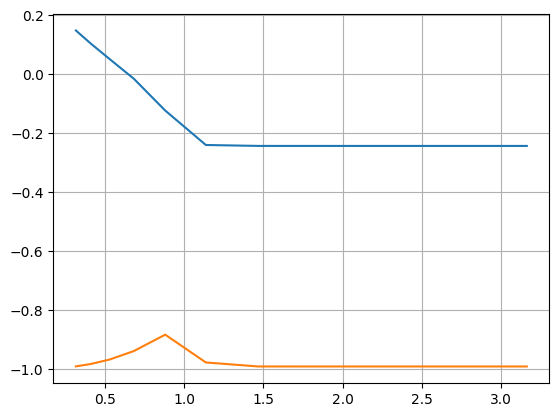

In [366]:
plt.plot(weights, O)
plt.grid()
plt.show()

In [367]:
mag_cal = mag @ A_hat.T + b_hat
norms = np.linalg.norm(mag_cal, axis=1)
overlaps = np.sum(acc * mag_cal, axis=1)

print(f"unit norm: {np.mean(norms):.03f} +/- {np.std(norms):.03f}")
print(f"overlaps : {np.mean(overlaps):.03f} +/- {np.std(overlaps):.03f}")

unit norm: 0.994 +/- 0.046
overlaps : -0.493 +/- 0.053


## IPOPT

In [368]:
import numpy as np
import cyipopt
from scipy.spatial.transform import Rotation


# Symmetric 4x4 parameter ordering:
# (00, 11, 22, 33, 01, 02, 03, 12, 13, 23)
Q_PAIRS = (
    (0, 0), (1, 1), (2, 2), (3, 3),
    (0, 1), (0, 2), (0, 3),
    (1, 2), (1, 3), (2, 3),
)


def q_to_matrix(q):
    Q = np.zeros((4, 4))
    for value, (i, j) in zip(q, Q_PAIRS):
        Q[i, j] = Q[j, i] = value
    return Q


def matrix_to_q(Q):
    return np.array([Q[i, j] for i, j in Q_PAIRS])


def quadratic_features(x):
    """phi(x)^T q = x^T Q x."""
    return np.array([
        x[0] ** 2,
        x[1] ** 2,
        x[2] ** 2,
        x[3] ** 2,
        2 * x[0] * x[1],
        2 * x[0] * x[2],
        2 * x[0] * x[3],
        2 * x[1] * x[2],
        2 * x[1] * x[3],
        2 * x[2] * x[3],
    ])


class StreamingExactCalibration:
    """
    Decision variables:
        W: 3x4 affine calibration matrix
        Q: symmetric 4x4 matrix

    Objective:
        alpha/2 * mean[(a^T W x - T)^2]
      + beta /2 * mean[(x^T Q x - 1)^2]

    Exact constraints:
        Q = W^T W
    """

    def __init__(self, target_dot, alpha=1.0, beta=1.0):
        self.T = float(target_dot)
        self.alpha = float(alpha)
        self.beta = float(beta)

        self.Ha = np.zeros((12, 12))
        self.ga = np.zeros(12)

        self.Hn = np.zeros((10, 10))
        self.gn = np.zeros(10)

        self.n = 0

        # Lower-triangular indices required by Ipopt.
        self.hess_rows, self.hess_cols = np.tril_indices(22)

        # Constant Hessian of each equality constraint.
        self.constraint_hessians = self._make_constraint_hessians()

    def update(self, mag_raw, acc, weight=1.0):
        mag_raw = np.asarray(mag_raw, dtype=float)
        acc = np.asarray(acc, dtype=float)

        acc = acc / np.linalg.norm(acc)
        x = np.r_[mag_raw, 1.0]

        # a^T W x = z^T vec_row(W)
        z = np.kron(acc, x)

        # x^T Q x = phi^T q
        phi = quadratic_features(x)

        self.Ha += weight * np.outer(z, z)
        self.ga += weight * self.T * z

        self.Hn += weight * np.outer(phi, phi)
        self.gn += weight * phi

        self.n += 1

    def _split(self, theta):
        W = theta[:12].reshape(3, 4)
        q = theta[12:]
        return W, q

    def objective(self, theta):
        w = theta[:12]
        q = theta[12:]
        scale = 1.0 / max(self.n, 1)

        return 0.5 * scale * (
            self.alpha * (w @ self.Ha @ w - 2 * self.ga @ w)
            + self.beta * (q @ self.Hn @ q - 2 * self.gn @ q)
        )

    def gradient(self, theta):
        w = theta[:12]
        q = theta[12:]
        scale = 1.0 / max(self.n, 1)

        return scale * np.r_[
            self.alpha * (self.Ha @ w - self.ga),
            self.beta * (self.Hn @ q - self.gn),
        ]

    def constraints(self, theta):
        W, q = self._split(theta)
        gram = W.T @ W

        return np.array([
            q[k] - gram[i, j]
            for k, (i, j) in enumerate(Q_PAIRS)
        ])

    def jacobian(self, theta):
        W, _ = self._split(theta)

        # Dense 10x22 Jacobian.
        J = np.zeros((10, 22))

        for k, (p, q) in enumerate(Q_PAIRS):
            # Derivative with respect to q_k.
            J[k, 12 + k] = 1.0

            # Derivative of -(W^T W)_{pq}.
            for row in range(3):
                wp = 4 * row + p
                wq = 4 * row + q

                if p == q:
                    J[k, wp] = -2.0 * W[row, p]
                else:
                    J[k, wp] = -W[row, q]
                    J[k, wq] = -W[row, p]

        return J.ravel(order="C")

    def _make_constraint_hessians(self):
        """
        Hessians of:
            c_pq = Q_pq - sum_r W[r,p] W[r,q].

        Only the W-W blocks are nonzero.
        """
        hessians = np.zeros((10, 22, 22))

        for k, (p, q) in enumerate(Q_PAIRS):
            for row in range(3):
                wp = 4 * row + p
                wq = 4 * row + q

                if p == q:
                    hessians[k, wp, wp] = -2.0
                else:
                    hessians[k, wp, wq] = -1.0
                    hessians[k, wq, wp] = -1.0

        return hessians

    def hessianstructure(self):
        return self.hess_rows, self.hess_cols

    def hessian(self, theta, lagrange, obj_factor):
        scale = 1.0 / max(self.n, 1)

        H = np.zeros((22, 22))

        # Objective Hessian.
        H[:12, :12] = obj_factor * scale * self.alpha * self.Ha
        H[12:, 12:] = obj_factor * scale * self.beta * self.Hn

        # Equality-constraint Hessians.
        H += np.tensordot(
            lagrange,
            self.constraint_hessians,
            axes=(0, 0),
        )

        return H[self.hess_rows, self.hess_cols]

    def solve(self, W0=None):
        if self.n == 0:
            raise ValueError("No samples have been accumulated.")

        if W0 is None:
            # Alignment-only least-squares initialization.
            ridge = 1e-8 * np.eye(12)
            w0 = np.linalg.solve(self.Ha + ridge, self.ga)
            W0 = w0.reshape(3, 4)

        # Start exactly feasible: Q0 = W0^T W0.
        Q0 = W0.T @ W0
        theta0 = np.r_[W0.ravel(), matrix_to_q(Q0)]

        nlp = cyipopt.Problem(
            n=22,
            m=10,
            problem_obj=self,
            lb=np.full(22, -np.inf),
            ub=np.full(22, np.inf),
            cl=np.zeros(10),
            cu=np.zeros(10),
        )

        nlp.add_option("tol", 1e-9)
        nlp.add_option("constr_viol_tol", 1e-10)
        nlp.add_option("max_iter", 500)
        nlp.add_option("mu_strategy", "adaptive")
        nlp.add_option("hessian_approximation", "exact")
        nlp.add_option("print_level", 0)

        theta, info = nlp.solve(theta0)

        W, q = self._split(theta)
        Q = q_to_matrix(q)

        return W, Q, info

In [369]:
rng = np.random.default_rng()

m_lab = np.array([0.4, 0.0, 0.9])
m_lab /= np.linalg.norm(m_lab)

a_lab = np.array([0.0, 0.0, -1.0])
T = a_lab @ m_lab

# Raw magnetometer model:
# m_raw = D_true @ m_physical + shift_true
D_true = Rotation.random(random_state=rng).as_matrix() @ np.diag(np.random.rand(3))
shift_true = np.random.rand(3) * 2 - 1

cal = StreamingExactCalibration(
    target_dot=T,
    alpha=1.0,
    beta=1.0,
)

noise = 0.05
for _ in range(500):
    R = Rotation.random(random_state=rng).as_matrix()

    acc = R @ a_lab + noise * rng.normal(size=3)
    mag_raw = (
        D_true @ (R @ m_lab)
        + shift_true
        + noise * rng.normal(size=3)
    )

    cal.update(mag_raw, acc)

W_hat, Q_hat, info = cal.solve()

A_hat = W_hat[:, :3]
b_hat = W_hat[:, 3]

A_expected = np.linalg.inv(D_true)
b_expected = -A_expected @ shift_true

print("Recovered A:\n", A_hat)
print("Expected A:\n", A_expected)

print("\nRecovered b:", b_hat)
print("Expected b:", b_expected)

print("\nExact coupling error:",
      np.linalg.norm(Q_hat - W_hat.T @ W_hat))

print("Ipopt status:", info["status_msg"])

Recovered A:
 [[ 0.111  2.751  1.047]
 [-1.068 -0.058  0.296]
 [ 0.78  -1.058  3.012]]
Expected A:
 [[ 0.112  3.051  1.112]
 [-1.075 -0.054  0.257]
 [ 0.857 -1.239  3.313]]

Recovered b: [ 2.04  -0.091 -0.959]
Expected b: [ 2.286 -0.078 -1.111]

Exact coupling error: 2.5438405243138005e-15
Ipopt status: b'Algorithm terminated successfully at a locally optimal point, satisfying the convergence tolerances (can be specified by options).'
